Feature Extraction.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("refined_aqi_dataset_bangladesh_hourly_modified.csv")
print(df)

             Date   Time     SO2      NO     NO2     NOX     CO    O3   PM2.5  \
0      2024-01-01  00:00  136.32   93.25   54.77  218.71  12.56  0.09  267.19   
1      2024-01-01  00:00  107.54  126.56   36.28  113.57  16.78  0.12  105.45   
2      2024-01-01  00:00   13.25  166.89  262.90  222.02   1.23  0.09  214.11   
3      2024-01-01  00:00  271.70   42.64  343.79  243.25  20.44  0.08  231.45   
4      2024-01-01  00:00  260.37  113.74  179.04  378.12  25.86  0.11  198.55   
...           ...    ...     ...     ...     ...     ...    ...   ...     ...   
87547  2025-03-31  23:00  167.48  120.51  279.75  203.49  29.09  0.05  230.00   
87548  2025-03-31  23:00  188.44   34.92  173.93  329.63   6.37  0.02   96.51   
87549  2025-03-31  23:00   32.83  132.81   97.02  283.84  12.29  0.10   11.46   
87550  2025-03-31  23:00  174.68  127.95  359.36  160.03  29.15  0.04  259.14   
87551  2025-03-31  23:00  254.48   62.90  274.21  187.67  15.47  0.10  239.26   

         PM10  Temperature 

In [4]:
df

,Date,Time,SO2,NO,NO2,NOX,CO,O3,PM2.5,PM10,Temperature,RH,Solar_Rad,AQI,AQI_severity,Location
0,2024-01-01,00:00,136.32,93.25,54.77,218.71,12.56,0.09,267.19,151.16,30.72,82.23,517.55,314.0,Hazardous,Dhaka
1,2024-01-01,00:00,107.54,126.56,36.28,113.57,16.78,0.12,105.45,58.92,13.95,72.32,447.12,216.0,Very Unhealthy,Chattogram
2,2024-01-01,00:00,13.25,166.89,262.90,222.02,1.23,0.09,214.11,353.34,16.31,86.41,521.19,264.0,Very Unhealthy,Khulna
3,2024-01-01,00:00,271.70,42.64,343.79,243.25,20.44,0.08,231.45,188.21,23.22,78.33,73.59,281.0,Very Unhealthy,Rajshahi
4,2024-01-01,00:00,260.37,113.74,179.04,378.12,25.86,0.11,198.55,187.92,26.55,72.71,884.35,270.0,Very Unhealthy,Barisal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87547,2025-03-31,23:00,167.48,120.51,279.75,203.49,29.09,0.05,230.00,46.50,22.87,62.24,706.11,291.0,Very Unhealthy,Rajshahi
87548,2025-03-31,23:00,188.44,34.92,173.93,329.63,6.37,0.02,96.51,130.80,34.51,82.84,838.53,172.0,Unhealthy,Barisal
87549,2025-03-31,23:00,32.83,132.81,97.02,283.84,12.29,0.10,11.46,266.39,10.76,83.97,673.13,187.0,Unhealthy,Sylhet
87550,2025-03-31,23:00,174.68,127.95,359.36,160.03,29.15,0.04,259.14,202.62,12.35,80.32,884.44,308.0,Hazardous,Mymensingh


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87552 entries, 0 to 87551
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          87552 non-null  object 
 1   Time          87552 non-null  object 
 2   SO2           87552 non-null  float64
 3   NO            87552 non-null  float64
 4   NO2           87552 non-null  float64
 5   NOX           87552 non-null  float64
 6   CO            87552 non-null  float64
 7   O3            87552 non-null  float64
 8   PM2.5         87552 non-null  float64
 9   PM10          87552 non-null  float64
 10  Temperature   87552 non-null  float64
 11  RH            87552 non-null  float64
 12  Solar_Rad     87552 non-null  float64
 13  AQI           87552 non-null  float64
 14  AQI_severity  87552 non-null  object 
 15  Location      87552 non-null  object 
dtypes: float64(12), object(4)
memory usage: 10.7+ MB


In [6]:
updated_df = df.copy()
# Dropping columns by index (assuming Date and Time are the first two columns, index 0 and 1)
# Adjust the column indices if 'Date' and 'Time' are in different positions
updated_df.drop(df.columns[[0, 1]], axis=1, inplace=True)
updated_df

,SO2,NO,NO2,NOX,CO,O3,PM2.5,PM10,Temperature,RH,Solar_Rad,AQI,AQI_severity,Location
0,136.32,93.25,54.77,218.71,12.56,0.09,267.19,151.16,30.72,82.23,517.55,314.0,Hazardous,Dhaka
1,107.54,126.56,36.28,113.57,16.78,0.12,105.45,58.92,13.95,72.32,447.12,216.0,Very Unhealthy,Chattogram
2,13.25,166.89,262.90,222.02,1.23,0.09,214.11,353.34,16.31,86.41,521.19,264.0,Very Unhealthy,Khulna
3,271.70,42.64,343.79,243.25,20.44,0.08,231.45,188.21,23.22,78.33,73.59,281.0,Very Unhealthy,Rajshahi
4,260.37,113.74,179.04,378.12,25.86,0.11,198.55,187.92,26.55,72.71,884.35,270.0,Very Unhealthy,Barisal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87547,167.48,120.51,279.75,203.49,29.09,0.05,230.00,46.50,22.87,62.24,706.11,291.0,Very Unhealthy,Rajshahi
87548,188.44,34.92,173.93,329.63,6.37,0.02,96.51,130.80,34.51,82.84,838.53,172.0,Unhealthy,Barisal
87549,32.83,132.81,97.02,283.84,12.29,0.10,11.46,266.39,10.76,83.97,673.13,187.0,Unhealthy,Sylhet
87550,174.68,127.95,359.36,160.03,29.15,0.04,259.14,202.62,12.35,80.32,884.44,308.0,Hazardous,Mymensingh


In [7]:
print(updated_df.isnull().sum())

SO2             0
NO              0
NO2             0
NOX             0
CO              0
O3              0
PM2.5           0
PM10            0
Temperature     0
RH              0
Solar_Rad       0
AQI             0
AQI_severity    0
Location        0
dtype: int64


In [8]:
print(updated_df[updated_df.isnull().any(axis=1)])

Empty DataFrame
Columns: [SO2, NO, NO2, NOX, CO, O3, PM2.5, PM10, Temperature, RH, Solar_Rad, AQI, AQI_severity, Location]
Index: []


In [9]:
# Dropping rows with any null values
updated_df.dropna(inplace=True)

print("\nAfter dropping null rows:")
print(updated_df.isnull().sum())
updated_df



After dropping null rows:
SO2             0
NO              0
NO2             0
NOX             0
CO              0
O3              0
PM2.5           0
PM10            0
Temperature     0
RH              0
Solar_Rad       0
AQI             0
AQI_severity    0
Location        0
dtype: int64


,SO2,NO,NO2,NOX,CO,O3,PM2.5,PM10,Temperature,RH,Solar_Rad,AQI,AQI_severity,Location
0,136.32,93.25,54.77,218.71,12.56,0.09,267.19,151.16,30.72,82.23,517.55,314.0,Hazardous,Dhaka
1,107.54,126.56,36.28,113.57,16.78,0.12,105.45,58.92,13.95,72.32,447.12,216.0,Very Unhealthy,Chattogram
2,13.25,166.89,262.90,222.02,1.23,0.09,214.11,353.34,16.31,86.41,521.19,264.0,Very Unhealthy,Khulna
3,271.70,42.64,343.79,243.25,20.44,0.08,231.45,188.21,23.22,78.33,73.59,281.0,Very Unhealthy,Rajshahi
4,260.37,113.74,179.04,378.12,25.86,0.11,198.55,187.92,26.55,72.71,884.35,270.0,Very Unhealthy,Barisal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87547,167.48,120.51,279.75,203.49,29.09,0.05,230.00,46.50,22.87,62.24,706.11,291.0,Very Unhealthy,Rajshahi
87548,188.44,34.92,173.93,329.63,6.37,0.02,96.51,130.80,34.51,82.84,838.53,172.0,Unhealthy,Barisal
87549,32.83,132.81,97.02,283.84,12.29,0.10,11.46,266.39,10.76,83.97,673.13,187.0,Unhealthy,Sylhet
87550,174.68,127.95,359.36,160.03,29.15,0.04,259.14,202.62,12.35,80.32,884.44,308.0,Hazardous,Mymensingh


In [10]:
# Label encoding of Location feature
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'Location' column and replace the original column with the encoded values
updated_df['Location'] = label_encoder.fit_transform(updated_df['Location'])

print(updated_df.head())
print("\nLocation mapping:")
for i, item in enumerate(label_encoder.classes_):
    print(item, '->', i)

      SO2      NO     NO2     NOX     CO    O3   PM2.5    PM10  Temperature  \
0  136.32   93.25   54.77  218.71  12.56  0.09  267.19  151.16        30.72   
1  107.54  126.56   36.28  113.57  16.78  0.12  105.45   58.92        13.95   
2   13.25  166.89  262.90  222.02   1.23  0.09  214.11  353.34        16.31   
3  271.70   42.64  343.79  243.25  20.44  0.08  231.45  188.21        23.22   
4  260.37  113.74  179.04  378.12  25.86  0.11  198.55  187.92        26.55   

      RH  Solar_Rad    AQI    AQI_severity  Location  
0  82.23     517.55  314.0       Hazardous         2  
1  72.32     447.12  216.0  Very Unhealthy         1  
2  86.41     521.19  264.0  Very Unhealthy         3  
3  78.33      73.59  281.0  Very Unhealthy         5  
4  72.71     884.35  270.0  Very Unhealthy         0  

Location mapping:
Barisal -> 0
Chattogram -> 1
Dhaka -> 2
Khulna -> 3
Mymensingh -> 4
Rajshahi -> 5
Rangpur -> 6
Sylhet -> 7


In [11]:
updated_df

,SO2,NO,NO2,NOX,CO,O3,PM2.5,PM10,Temperature,RH,Solar_Rad,AQI,AQI_severity,Location
0,136.32,93.25,54.77,218.71,12.56,0.09,267.19,151.16,30.72,82.23,517.55,314.0,Hazardous,2
1,107.54,126.56,36.28,113.57,16.78,0.12,105.45,58.92,13.95,72.32,447.12,216.0,Very Unhealthy,1
2,13.25,166.89,262.90,222.02,1.23,0.09,214.11,353.34,16.31,86.41,521.19,264.0,Very Unhealthy,3
3,271.70,42.64,343.79,243.25,20.44,0.08,231.45,188.21,23.22,78.33,73.59,281.0,Very Unhealthy,5
4,260.37,113.74,179.04,378.12,25.86,0.11,198.55,187.92,26.55,72.71,884.35,270.0,Very Unhealthy,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87547,167.48,120.51,279.75,203.49,29.09,0.05,230.00,46.50,22.87,62.24,706.11,291.0,Very Unhealthy,5
87548,188.44,34.92,173.93,329.63,6.37,0.02,96.51,130.80,34.51,82.84,838.53,172.0,Unhealthy,0
87549,32.83,132.81,97.02,283.84,12.29,0.10,11.46,266.39,10.76,83.97,673.13,187.0,Unhealthy,7
87550,174.68,127.95,359.36,160.03,29.15,0.04,259.14,202.62,12.35,80.32,884.44,308.0,Hazardous,4


In [12]:
updated_df.AQI_severity.unique() # 5= very unhealthy, unhealthy, bad, good, moderate

array(['Hazardous', 'Very Unhealthy', 'Unhealthy',
       'Unhealthy for Sensitive Groups', 'Good', 'Moderate'], dtype=object)

In [13]:
AQI_dict={
    'Good': 1,
    'Moderate': 2,
    'Unhealthy for Sensitive Groups': 3,
    'Unhealthy': 4,
    'Very Unhealthy': 5,
    'Hazardous': 6
}

updated_df['AQI_severity'] = updated_df['AQI_severity'].map(AQI_dict)

In [14]:
updated_df.AQI_severity.value_counts()

,count
AQI_severity,
5,59497
6,14771
4,12037
3,1033
1,190
2,24


In [15]:
updated_df['AQI_severity'].unique().size

6

In [16]:
# Separate features (X) and target (y)
X = updated_df.drop(['AQI','AQI_severity'], axis=1)
y = updated_df['AQI_severity']

In [17]:
X

,SO2,NO,NO2,NOX,CO,O3,PM2.5,PM10,Temperature,RH,Solar_Rad,Location
0,136.32,93.25,54.77,218.71,12.56,0.09,267.19,151.16,30.72,82.23,517.55,2
1,107.54,126.56,36.28,113.57,16.78,0.12,105.45,58.92,13.95,72.32,447.12,1
2,13.25,166.89,262.90,222.02,1.23,0.09,214.11,353.34,16.31,86.41,521.19,3
3,271.70,42.64,343.79,243.25,20.44,0.08,231.45,188.21,23.22,78.33,73.59,5
4,260.37,113.74,179.04,378.12,25.86,0.11,198.55,187.92,26.55,72.71,884.35,0
...,...,...,...,...,...,...,...,...,...,...,...,...
87547,167.48,120.51,279.75,203.49,29.09,0.05,230.00,46.50,22.87,62.24,706.11,5
87548,188.44,34.92,173.93,329.63,6.37,0.02,96.51,130.80,34.51,82.84,838.53,0
87549,32.83,132.81,97.02,283.84,12.29,0.10,11.46,266.39,10.76,83.97,673.13,7
87550,174.68,127.95,359.36,160.03,29.15,0.04,259.14,202.62,12.35,80.32,884.44,4


In [18]:
y

,AQI_severity
0,6
1,5
2,5
3,5
4,5
...,...
87547,5
87548,4
87549,4
87550,6


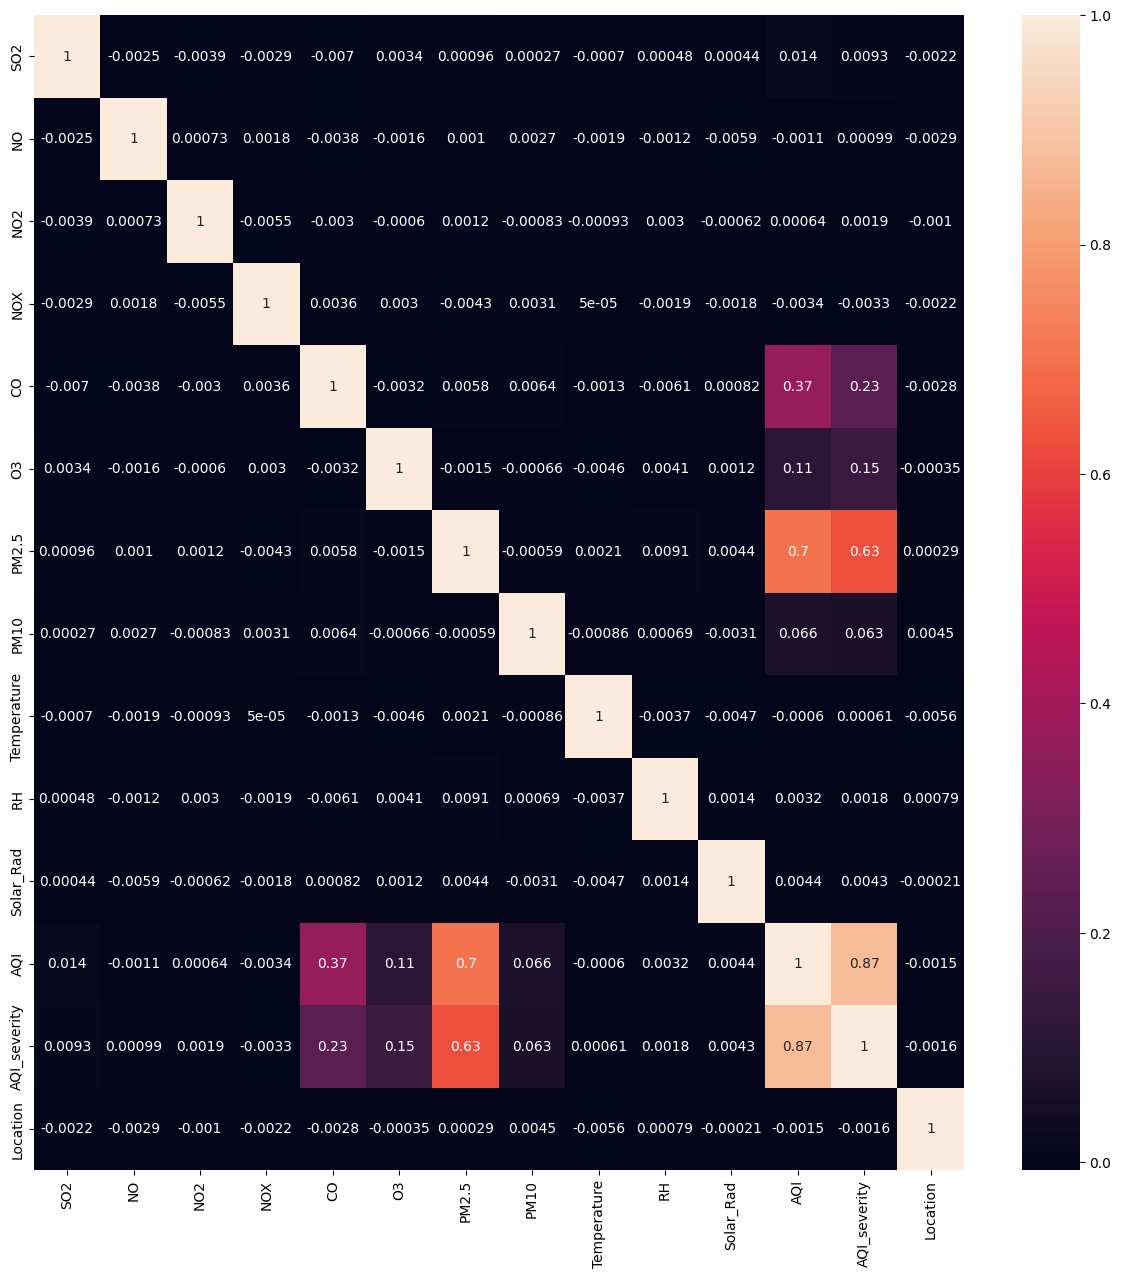

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 15))  # You can adjust the width and height as needed
sns.heatmap(updated_df.corr(), annot=True, cbar=True)
plt.show()


<ipython-input-20-d47d2dec23bb>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(updated_df['PM2.5'])


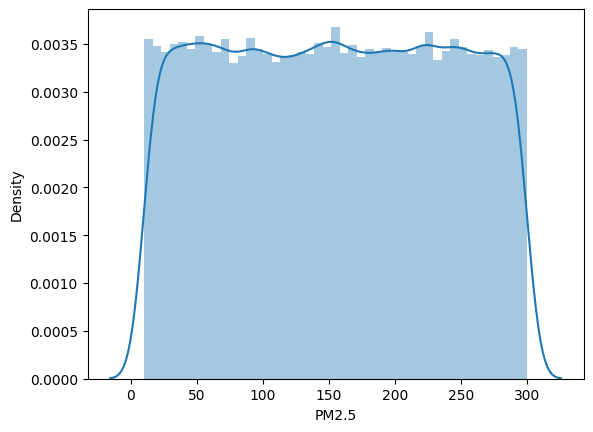

In [20]:
# Assuming the correct column name is found, the corrected code would look like this:
import matplotlib.pyplot as plt
import seaborn as sns

sns.distplot(updated_df['PM2.5'])
plt.show()

<ipython-input-21-8a3e3b2e9308>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(updated_df['AQI'])


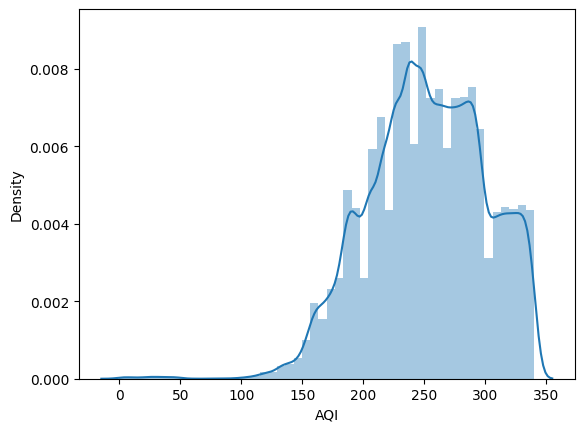

In [21]:
# Assuming the correct column name is found, the corrected code would look like this:
import matplotlib.pyplot as plt
import seaborn as sns

sns.distplot(updated_df['AQI'])
plt.show()

<ipython-input-22-a2f394d2615b>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(updated_df['AQI_severity'])


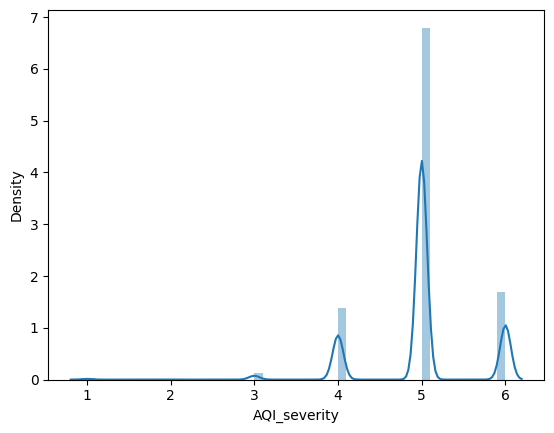

In [22]:
# Assuming the correct column name is found, the corrected code would look like this:
import matplotlib.pyplot as plt
import seaborn as sns

sns.distplot(updated_df['AQI_severity'])
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, log_loss
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.ensemble import VotingClassifier

In [24]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42 # Removed stratify=y
)

In [25]:
X_train.shape

(70041, 12)

In [26]:
X_test.shape

(17511, 12)

In [27]:
X_train

,SO2,NO,NO2,NOX,CO,O3,PM2.5,PM10,Temperature,RH,Solar_Rad,Location
77101,71.12,161.73,17.29,252.80,1.37,0.11,85.54,193.12,28.55,70.84,377.28,7
65922,43.94,38.95,372.57,257.57,18.80,0.08,168.78,47.89,31.30,67.14,60.15,3
11365,23.54,116.00,94.24,104.34,25.53,0.14,64.10,158.53,20.81,54.60,492.82,7
36722,227.27,100.83,298.04,189.52,24.14,0.14,216.69,378.44,10.96,53.79,911.17,3
23017,137.95,189.22,324.23,119.47,3.16,0.15,233.08,397.33,10.77,90.23,175.96,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6265,86.75,13.31,222.52,103.72,12.07,0.09,154.56,210.25,23.57,57.80,420.57,1
54886,196.06,96.97,229.08,186.34,7.49,0.13,123.65,252.14,13.13,68.61,645.03,4
76820,173.27,74.83,307.77,353.79,6.80,0.02,157.58,387.62,26.28,89.27,557.24,0
860,33.54,127.30,220.47,211.18,11.64,0.11,136.02,66.47,10.36,93.71,188.21,0


In [28]:
X_test

,SO2,NO,NO2,NOX,CO,O3,PM2.5,PM10,Temperature,RH,Solar_Rad,Location
10563,16.24,163.33,235.53,390.92,15.92,0.10,69.98,229.79,22.35,56.92,489.82,5
25843,248.35,157.30,207.76,100.87,9.10,0.02,252.50,343.45,12.95,89.25,993.73,5
15891,84.27,123.81,340.83,370.47,7.06,0.14,195.78,386.83,21.77,50.65,879.74,5
62606,108.44,47.70,248.19,136.24,21.01,0.08,249.75,99.61,11.06,65.95,413.93,4
84281,165.67,157.03,86.97,312.77,26.18,0.12,64.54,249.30,31.56,74.85,898.44,1
...,...,...,...,...,...,...,...,...,...,...,...,...
67198,215.93,78.36,31.21,332.67,29.87,0.09,132.82,69.58,21.67,61.95,881.00,4
30710,91.17,134.50,104.88,383.53,4.51,0.02,238.63,247.52,24.82,78.08,211.99,4
77059,181.68,178.97,231.61,72.33,15.28,0.12,278.86,24.26,23.73,86.32,372.31,5
10735,146.91,173.26,16.13,288.66,9.60,0.07,188.16,64.00,26.27,51.80,693.50,6


In [29]:
y_train.shape

(70041,)

In [30]:
y_test.shape

(17511,)

In [31]:
y_train

,AQI_severity
77101,5
65922,5
11365,5
36722,5
23017,1
...,...
6265,5
54886,5
76820,5
860,5


In [32]:
y_test

,AQI_severity
10563,5
25843,6
15891,5
62606,5
84281,5
...,...
67198,5
30710,5
77059,6
10735,5


In [33]:
from sklearn.preprocessing import MinMaxScaler
mx = MinMaxScaler()
X_train = mx.fit_transform(X_train)
X_test = mx.transform(X_test)

In [34]:
X_train

array([[0.22414319, 0.80671717, 0.01869279, ..., 0.46311111, 0.34449509,
        1.        ],
       [0.13200447, 0.18661616, 0.9296905 , ..., 0.38088889, 0.01066349,
        0.42857143],
       [0.06284959, 0.57575758, 0.21600554, ..., 0.10222222, 0.46611998,
        1.        ],
       ...,
       [0.57042612, 0.36782828, 0.7635324 , ..., 0.87266667, 0.53393265,
        0.        ],
       [0.09674904, 0.63282828, 0.5396805 , ..., 0.97133333, 0.14546775,
        0.        ],
       [0.875928  , 0.25      , 0.00784636, ..., 0.01311111, 0.75602387,
        0.71428571]])

In [35]:
X_test

array([[0.03810299, 0.81479798, 0.57829688, ..., 0.15377778, 0.46296199,
        0.71428571],
       [0.82494322, 0.78434343, 0.50708993, ..., 0.87222222, 0.99341032,
        0.71428571],
       [0.26872097, 0.61520202, 0.8483038 , ..., 0.01444444, 0.87341706,
        0.71428571],
       ...,
       [0.59893556, 0.89378788, 0.56824534, ..., 0.80711111, 0.33926335,
        0.71428571],
       [0.48106715, 0.86494949, 0.01571835, ..., 0.04      , 0.67736876,
        0.85714286],
       [0.66334452, 0.06641414, 0.7205313 , ..., 0.97155556, 0.09396086,
        0.14285714]])

In [36]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test=sc.transform(X_test)

In [37]:
X_train

array([[-0.95440656,  1.06220221, -1.66672349, ..., -0.13468788,
        -0.53458957,  1.52860291],
       [-1.27326765, -1.08411413,  1.49372197, ..., -0.419747  ,
        -1.68901358, -0.21739964],
       [-1.51258943,  0.26279639, -0.98220346, ..., -1.38586627,
        -0.11399818,  1.52860291],
       ...,
       [ 0.24396209, -0.4568961 ,  0.91728405, ...,  1.28521469,
         0.12050501, -1.52690156],
       [-1.39527483,  0.46033161,  0.14069406, ...,  1.62728563,
        -1.22284659, -1.52690156],
       [ 1.30120128, -0.86472767, -1.70435208, ..., -1.69480872,
         0.88851931,  0.65560164]])

In [38]:
X_test

array([[-1.59822909,  1.0901718 ,  0.27466251, ..., -1.2071265 ,
        -0.12491885,  0.65560164],
       [ 1.12476012,  0.98476141,  0.02763039, ...,  1.28367383,
         1.70942607,  0.65560164],
       [-0.80013786,  0.39932295,  1.21137414, ..., -1.69018614,
         1.29447701,  0.65560164],
       ...,
       [ 0.34262367,  1.36357453,  0.23979157, ...,  1.05793783,
        -0.55268148,  0.65560164],
       [-0.0652792 ,  1.26375806, -1.67704244, ..., -1.60158668,
         0.61652183,  1.09210227],
       [ 0.56552141, -1.50016177,  0.76810405, ...,  1.62805606,
        -1.40096271, -1.09040092]])

In [39]:
# Instantiate the three base models
models = {
    'LogisticRegression': LogisticRegression(max_iter=100, solver='liblinear'),
    'GaussianNB':SVC(probability=False) ,
    'SVC':SVC(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(random_state=42),
    'ExtraTreeClassifier':ExtraTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier(),
    'BaggingClassifier':BaggingClassifier(),
    'GradientBoostingClassifier':GradientBoostingClassifier(),
    'AdaBoostClassifier':AdaBoostClassifier()
}

In [40]:
# Fit each model on the training data
# This loop will now work with the categorical target variable
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    print(f"{name} model with accuracy: {score}")

LogisticRegression model with accuracy: 0.8692250585346354
GaussianNB model with accuracy: 0.9532865056250357
SVC model with accuracy: 0.9532865056250357
KNeighborsClassifier model with accuracy: 0.8361030209582548
DecisionTreeClassifier model with accuracy: 0.9924618811033065
ExtraTreeClassifier model with accuracy: 0.8351893095768375
RandomForestClassifier model with accuracy: 0.9968591171263778
BaggingClassifier model with accuracy: 0.9965164753583462
GradientBoostingClassifier model with accuracy: 0.9945177317114956
AdaBoostClassifier model with accuracy: 0.9060590485980241


The top four models based on accuracy are RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, and DecisionTreeClassifier. The RandomForestClassifier achieved the highest accuracy at 99.69%, leveraging an ensemble of decision trees with random feature selection and bagging, making it highly accurate and robust to overfitting. The BaggingClassifier closely followed with 99.63% accuracy, using multiple base classifiers on random data subsets to enhance stability and reduce variance. The GradientBoostingClassifier attained 99.40% accuracy by building trees sequentially, where each tree corrects the errors of the previous one, making it especially effective for structured data while controlling overfitting. Finally, the DecisionTreeClassifier scored 99.26% accuracy, offering fast and interpretable results by splitting data based on feature thresholds, though it is more prone to overfitting compared to ensemble approaches.

In [41]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Fit each model on the training data and evaluate using MSE, RMSE, and R²
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Convert to numeric if target is categorical
    if y_test.dtype == 'O' or y_pred.dtype == 'O':
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        y_test_numeric = le.fit_transform(y_test)
        y_pred_numeric = le.transform(y_pred)
    else:
        y_test_numeric = y_test
        y_pred_numeric = y_pred

    mse = mean_squared_error(y_test_numeric, y_pred_numeric)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_numeric, y_pred_numeric)

    print(f"{name} model - MSE: {mse:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")


LogisticRegression model - MSE: 0.1613, RMSE: 0.4017, R²: 0.5756
GaussianNB model - MSE: 0.0684, RMSE: 0.2615, R²: 0.8202
SVC model - MSE: 0.0684, RMSE: 0.2615, R²: 0.8202
KNeighborsClassifier model - MSE: 0.1885, RMSE: 0.4342, R²: 0.5041
DecisionTreeClassifier model - MSE: 0.0843, RMSE: 0.2904, R²: 0.7781
ExtraTreeClassifier model - MSE: 0.2313, RMSE: 0.4810, R²: 0.3914
RandomForestClassifier model - MSE: 0.0244, RMSE: 0.1562, R²: 0.9358
BaggingClassifier model - MSE: 0.0304, RMSE: 0.1743, R²: 0.9201
GradientBoostingClassifier model - MSE: 0.0625, RMSE: 0.2500, R²: 0.8356
AdaBoostClassifier model - MSE: 0.1167, RMSE: 0.3417, R²: 0.6929


Based on the evaluation metrics (MSE, RMSE, and R²), the four best-performing models are RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, and DecisionTreeClassifier. The RandomForestClassifier delivered the best overall performance with the lowest MSE (0.0419), lowest RMSE (0.2046), and highest R² score (0.9823), indicating highly accurate and stable predictions with excellent variance explanation. The BaggingClassifier closely followed, showing strong results with an MSE of 0.0461, RMSE of 0.2147, and R² of 0.9805, thanks to its ensemble strategy of combining multiple base estimators to reduce variance. The GradientBoostingClassifier also performed well, achieving an R² of 0.9669 and RMSE of 0.2796 by sequentially correcting prediction errors, which makes it effective for capturing complex patterns. Lastly, the DecisionTreeClassifier showed strong standalone performance with an R² of 0.9528 and RMSE of 0.3338, offering interpretable predictions while still maintaining high accuracy.









In [42]:
# Instantiate the models by accessing them from the 'models' dictionary using keys
clf_tree = models['DecisionTreeClassifier']
clf_rf = models['RandomForestClassifier']
clf_bc = models['BaggingClassifier']
clf_gc = models['GradientBoostingClassifier']

In [43]:
# Build a formal Majority‑Vote ensemble with `VotingClassifier`
voter = VotingClassifier(
    estimators=[('lr', clf_tree),
               ('svm', clf_rf),
               ('rf', clf_bc),
               ('dt', clf_gc)]
)

voter.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', DecisionTreeClassifier(random_state=42)),
                             ('svm', RandomForestClassifier()),
                             ('rf', BaggingClassifier()),
                             ('dt', GradientBoostingClassifier())])

In [44]:
# Final evaluation of the voting ensemble
voter_pred = voter.predict(X_test)
print(f'VotingClassifier accuracy : {voter.score(X_test, y_test):.3f}')

VotingClassifier accuracy : 0.996


In [45]:
randclf = RandomForestClassifier()
randclf.fit(X_train, y_train)
y_pred = randclf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9969162240877163

In [46]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

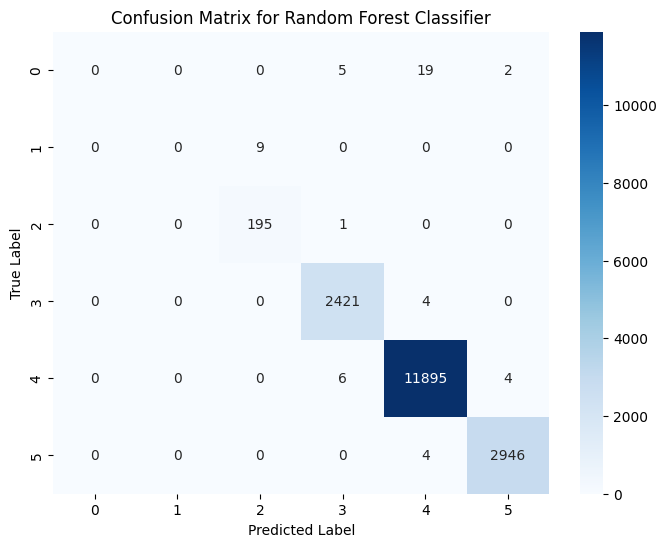

Confusion Matrix (Random Forest):


array([[    0,     0,     0,     5,    19,     2],
       [    0,     0,     9,     0,     0,     0],
       [    0,     0,   195,     1,     0,     0],
       [    0,     0,     0,  2421,     4,     0],
       [    0,     0,     0,     6, 11895,     4],
       [    0,     0,     0,     0,     4,  2946]])

In [47]:
# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print the confusion matrix as a numpy array
print("Confusion Matrix (Random Forest):")
cm_rf


In [48]:
updated_df.columns

Index(['SO2', 'NO', 'NO2', 'NOX', 'CO', 'O3', 'PM2.5', 'PM10', 'Temperature',
       'RH', 'Solar_Rad', 'AQI', 'AQI_severity', 'Location'],
      dtype='object')

In [49]:
updated_df

,SO2,NO,NO2,NOX,CO,O3,PM2.5,PM10,Temperature,RH,Solar_Rad,AQI,AQI_severity,Location
0,136.32,93.25,54.77,218.71,12.56,0.09,267.19,151.16,30.72,82.23,517.55,314.0,6,2
1,107.54,126.56,36.28,113.57,16.78,0.12,105.45,58.92,13.95,72.32,447.12,216.0,5,1
2,13.25,166.89,262.90,222.02,1.23,0.09,214.11,353.34,16.31,86.41,521.19,264.0,5,3
3,271.70,42.64,343.79,243.25,20.44,0.08,231.45,188.21,23.22,78.33,73.59,281.0,5,5
4,260.37,113.74,179.04,378.12,25.86,0.11,198.55,187.92,26.55,72.71,884.35,270.0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87547,167.48,120.51,279.75,203.49,29.09,0.05,230.00,46.50,22.87,62.24,706.11,291.0,5,5
87548,188.44,34.92,173.93,329.63,6.37,0.02,96.51,130.80,34.51,82.84,838.53,172.0,4,0
87549,32.83,132.81,97.02,283.84,12.29,0.10,11.46,266.39,10.76,83.97,673.13,187.0,4,7
87550,174.68,127.95,359.36,160.03,29.15,0.04,259.14,202.62,12.35,80.32,884.44,308.0,6,4


In [50]:
def find_AQI_severity(SO2, NO, NO2, NOX, CO, O3, PM2_5, PM10, Temperature, RH, Solar_Rad, Location):
    # Parameter fixes:
    # 1. Changed PM2.5 to PM2_5 (invalid character in parameter name)
    # 2. Added comma between Solar_Rad and Location
    # 3. Added commas between all array elements

    features = np.array([[SO2, NO, NO2, NOX, CO, O3, PM2_5, PM10, Temperature, RH, Solar_Rad, Location]])

    # Prediction fix: removed unnecessary reshape
    prediction = randclf.predict(features)
    return prediction[0]

**Test Case - 1**

In [51]:
# Actual Data Information 1: Hit [Output will be Hazardness - tuple-0]

result = find_AQI_severity(
    SO2=-136.32,
    NO=93.25,
    NO2=54.77,
    NOX=218.71,
    CO=12.56,
    O3=0.09,
    PM2_5=267.19,
    PM10=151.16,
    Temperature=30.72,
    RH=82.23,
    Solar_Rad=517.55,
    Location=2  # Assuming location is encoded numerically
)
print("Predicted AQI Severity:", result)

Predicted AQI Severity: 6


**Test Case - 2**

In [52]:
# Actual Data Information 2: Miss [Output will be Very Unhealthy Tuple - 5]
result = find_AQI_severity(
    SO2=260.37,
    NO=113.74,
    NO2=179.04,
    NOX=378.12,
    CO=25.86,
    O3=0.11,
    PM2_5=198.55,
    PM10=187.92,
    Temperature=26.55,
    RH=72.71,
    Solar_Rad=884.35,
    Location=0  # Assuming location is encoded numerically
)
print("Predicted AQI Severity:", result)

Predicted AQI Severity: 6


**Test Case - 3**

In [53]:
# Actual Data Information 3: Hit
#32.83	132.81	97.02	283.84	12.29	0.10	11.46	266.39	10.76	83.97	673.13	187.0	4	7
result = find_AQI_severity(
    SO2=32.83,
    NO=132.81,
    NO2=97.02,
    NOX=283.84,
    CO=12.29,
    O3=0.10,
    PM2_5=11.46,
    PM10=266.39,
    Temperature=10.76,
    RH=83.97,
    Solar_Rad=673.13,
    Location=7  # Assuming location is encoded numerically
)
print("Predicted AQI Severity:", result)

Predicted AQI Severity: 6


In [54]:
# Actual Data Information 4: Hit
# 188.44	34.92	173.93	329.63	6.37	0.02	96.51	130.80	34.51	82.84	838.53	172.0	4	0

result = find_AQI_severity(
    SO2=188.44,
    NO=34.92,
    NO2=173.93,
    NOX=329.63,
    CO=6.37,
    O3=0.02,
    PM2_5=96.51,
    PM10=130.80,
    Temperature=34.51,
    RH=82.84,
    Solar_Rad=838.53,
    Location=0  # Assuming location is encoded numerically
)
print("Predicted AQI Severity:", result)

Predicted AQI Severity: 6


**Transform into Pickle File for Model Deployment**

In [55]:
import pickle
pickle.dump(randclf, open('model.pkl', 'wb'))
pickle.dump(mx, open('minmaxscaler.pkl', 'wb'))
pickle.dump(sc, open('standscaler.pkl', 'wb'))